# Credit Card Fraud Detaction - EDA, Feature Engineering & Model Comparison

In [2]:
# Setup - imports
import os 
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


# Optional models
try:
    import xgboost as xgb
except Exception as e:
    xgb = None
    print('XGBoost not available:', e)

try:
    import lightgbm as lgb
except Exception as e:
    lgb = None
    print('LightGBM not available:', e)

import joblib
print('Setup Complete')

Setup Complete


In [3]:
# 1. Load data
DATA_PATH = '../data/raw/creditcard.csv'   # ensure file is in same directory
assert os.path.exists(DATA_PATH), f"Dataset not found at {DATA_PATH}. Please place creditcard.csv next to the notebook."
df = pd.read_csv(DATA_PATH)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Rows, Columns: (284807, 31)
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing values (top 20): 
 Time    0
V1      0
V2      0
V3      0
V4      0
V5      0
V6      0
V7      0
V8      0
V9      0
V10     0
V11     0
V12     0
V13     0
V14     0
V15     0
V16     0
V17     0
V18     0
V19     0
dtype: int64

Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Fraud ratio: 0.001727485630620034


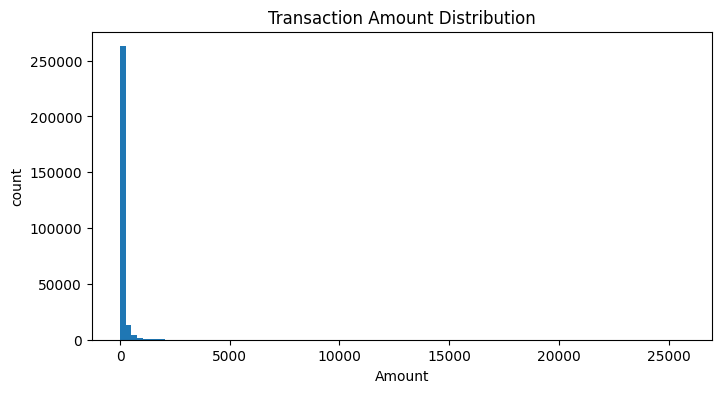

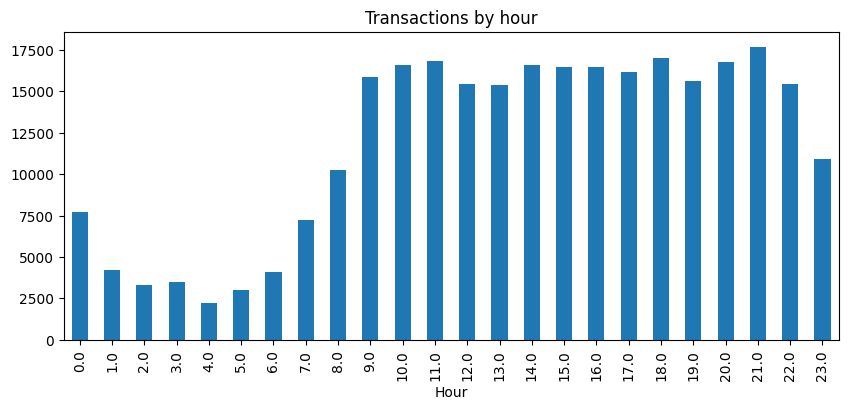

In [4]:
# 2. Quick EDA
print('Rows, Columns:', df.shape)
print(df.dtypes)
print('\nMissing values (top 20): \n', df.isnull().sum().sort_values(ascending=False).head(20))
target_col = 'Class'
print('\nTarget distribution:')
print(df[target_col].value_counts())
print('Fraud ratio:', df[target_col].mean())

# Amount distribution
plt.figure(figsize=(8,4))
plt.hist(df['Amount'], bins=100)
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('count')
plt.show()

# Time-based overview (the dataset's Time column in seconds since first transaction)
if 'Time' in df.columns:
    df['Hour'] = (df['Time'] // 3600) % 24
    plt.figure(figsize=(10,4))
    df.groupby('Hour').size().plot(kind='bar')
    plt.title('Transactions by hour')
    plt.show()

# Data Analysis

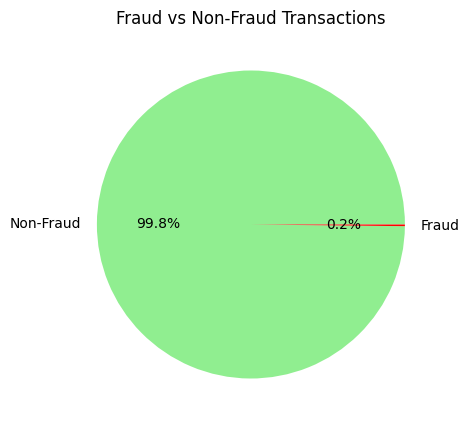

In [5]:
# Pie chart
plt.figure(figsize=(5,5))
plt.pie(df['Class'].value_counts().values, labels=['Non-Fraud', 'Fraud'], autopct='%1.1f%%', colors=['lightgreen', 'red'])
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()

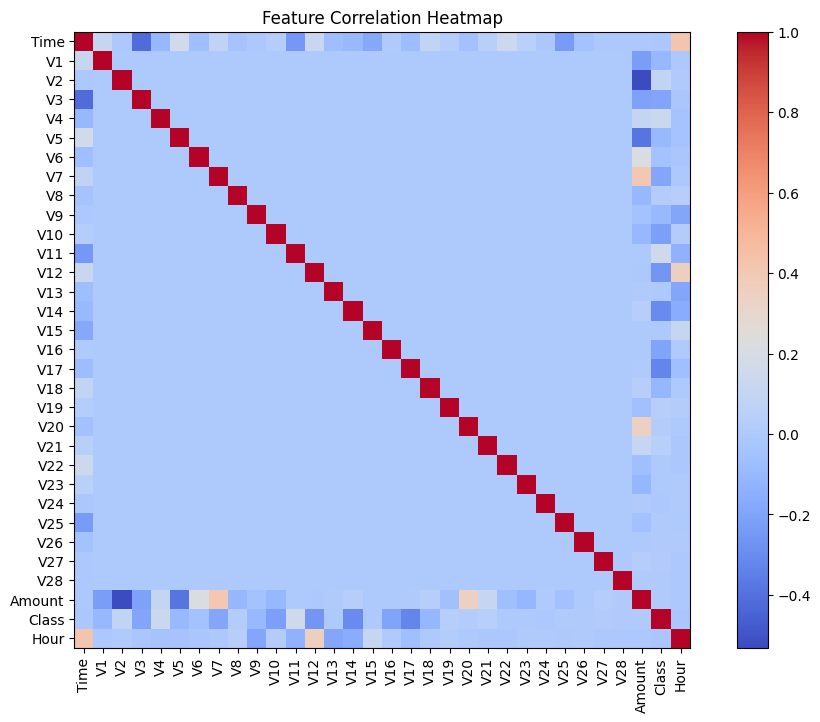

In [6]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
corr = df.corr()
plt.imshow(corr, cmap='coolwarm', interpolation = 'nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Feature Correlation Heatmap')
plt.show()

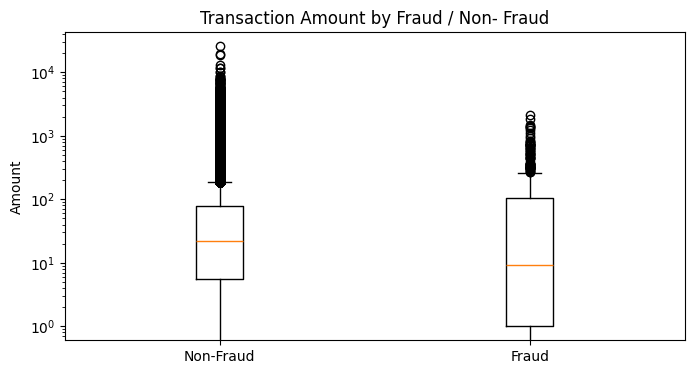

In [7]:
# Fraud vs Non-Fraud Amount
plt.figure(figsize=(8,4))
amount_nonfraud = df[df['Class']==0]['Amount']
amount_fraud = df[df['Class']==1]['Amount']
plt.boxplot([amount_nonfraud, amount_fraud], labels=['Non-Fraud', 'Fraud'])
plt.yscale('log')    # because amounts are skewed
plt.ylabel('Amount')
plt.title('Transaction Amount by Fraud / Non- Fraud')
plt.show()

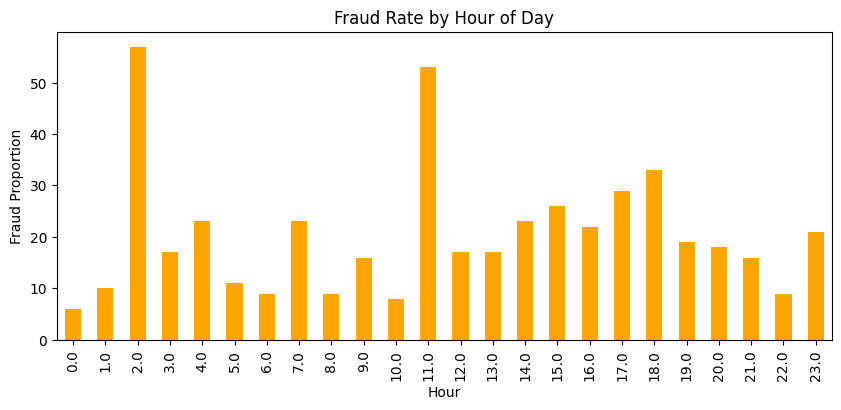

In [8]:
#Hourly fraud
hourly = df.groupby('Hour')['Class'].sum()
plt.figure(figsize=(10,4))
hourly.plot(kind='bar', color='orange')
plt.ylabel('Fraud Proportion')
plt.title('Fraud Rate by Hour of Day')
plt.show()

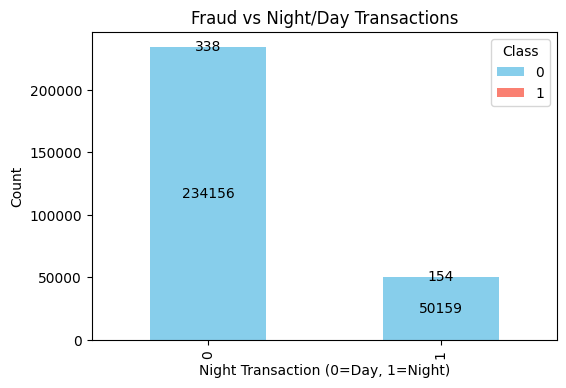

In [9]:
# Night vs Day Fraud
df['is_night'] = df['Hour'].isin([22, 23, 0, 1, 2, 3, 4, 5]).astype(int)

night_fraud = df.groupby(['is_night','Class']).size().unstack(fill_value=0)
ax = night_fraud.plot(kind='bar',stacked=True,figsize=(6,4),color=['skyblue','salmon'])
plt.xlabel('Night Transaction (0=Day, 1=Night)')
plt.ylabel('Count')
plt.title('Fraud vs Night/Day Transactions')
for container in ax.containers:
    ax.bar_label(container, label_type='center', fmt='%d')
plt.show()

# Preparing Data for Model Creation

In [10]:
legit = df[df.Class==0]
fraud = df[df['Class'] ==1]

In [11]:
legit_sample = legit.sample(n=492)
df = pd.concat([legit_sample,fraud],axis=0)

In [12]:
df['Class'].value_counts()


Class
0    492
1    492
Name: count, dtype: int64

In [13]:
df.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Hour,is_night
Class,,,,,,,,,,,,,,,,,,,,,
0,91464.390244,-0.027626,-0.023627,-0.009203,0.064010,-0.077619,-0.039466,-0.050302,0.078794,0.106877,...,-0.062728,0.059282,-0.040567,-0.009610,-0.030400,0.031410,0.006042,86.601972,13.813008,0.172764
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321,11.646341,0.313008


In [14]:
X = df.drop('Class',axis=1)
y = df['Class']

In [15]:
# Target column
target_col = 'Class'

# Copy dataset
df_fe = df.copy()
# Feature Engineering
# 1. Log Amount
df_fe['log_amount'] = np.log1p(df_fe['Amount'])

# 2. Amount to global mean ratio
global_mean = df_fe['Amount'].mean()
df_fe['amount_to_mean'] = df_fe['Amount'] / (global_mean + 1e-9)

# 3. High amount flag (above 99th percentile)
p99 = df_fe['Amount'].quantile(0.99)
df_fe['is_high_amount'] = (df_fe['Amount'] > p99).astype(int)

# 4. Night transaction feature
if 'Hour' in df_fe.columns:
    df_fe['is_night'] = df_fe['Hour'].isin([0,1,2,3,4,5,22,23]).astype(int)
else:
    df_fe['is_night'] = 0
# Create X and y (FINAL)
X = df_fe.drop(columns=[target_col])
y = df_fe[target_col]

print("Feature engineering complete.")
print("X shape:", X.shape)
print("y shape:", y.shape)


Feature engineering complete.
X shape: (984, 35)
y shape: (984,)


In [16]:
# 4. Train / Test split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Train: ', X_train.shape, 'Test:', X_test.shape)

# 🔥 Drop Time BEFORE scaling
if 'Time' in X_train.columns:
    X_train = X_train.drop(columns=['Time'])
    X_test = X_test.drop(columns=['Time'])

# Identify numeric features AFTER dropping Time
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Scaling
scaler = RobustScaler()
scaler.fit(X_train[numeric_features])

def prep(X_df):
    Xc = X_df.copy()
    Xc[numeric_features] = scaler.transform(Xc[numeric_features])
    return Xc

X_train_proc = prep(X_train)
X_test_proc = prep(X_test)

print('Processed data shapes:', X_train_proc.shape, X_test_proc.shape)


Train:  (787, 35) Test: (197, 35)
Processed data shapes: (787, 34) (197, 34)


In [17]:
# 5. Evaluation utilities
def evaluate_model(model, X_test, y_test, thresh=0.5, show_pr_curve=True):
    # obtain probabilities or scores
    if hasattr(model, 'predict_proba'):
        y_scores = model.predict_proba(X_test)[:,1]
    elif hasattr(model, 'decision_function'):
        s = model.decision_function(X_test)
        y_scores = (s - s.min())/(s.max()-s.min()+1e-9)
    else:
        y_scores = model.predict(X_test)
    y_pred = (y_scores >= thresh).astype(int)
    print('Classification report (threshold={}):'.format(thresh))
    print(classification_report(y_test, y_pred, digits=4))
    ap = average_precision_score(y_test, y_scores)
    roc = roc_auc_score(y_test, y_scores)
    cm = confusion_matrix(y_test, y_pred)
    print('Average precision (AUPRC):', ap)
    print('ROC AUC:', roc)
    print('Confusion matrix:\n', cm)
    if show_pr_curve:
        precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
        plt.figure(figsize=(6,4))
        plt.plot(recall, precision)
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'PR curve (AP={ap:.4f})')
        plt.show()
    return {'ap': ap, 'roc': roc, 'scores': y_scores}

In [18]:
# 6. Train baseline models
trained_models = {} 

# Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced', solver='saga')
lr.fit(X_train_proc, y_train)
trained_models['LogisticRegression'] = lr
print('Trained Logistic Regression')

# Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_train_proc, y_train)
trained_models['RandomForest'] = rf
print('Trained Random Forest')

# XGBoost 
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=(np.sum(y_train==0)/np.sum(y_train==1)))
xgb_clf.fit(X_train_proc, y_train)
trained_models['XGBoost'] = xgb_clf
print('Trained XGBoost')

Trained Logistic Regression
Trained Random Forest
Trained XGBoost



=== Model: LogisticRegression ===
Classification report (threshold=0.5):
              precision    recall  f1-score   support

           0     0.9485    0.9293    0.9388        99
           1     0.9300    0.9490    0.9394        98

    accuracy                         0.9391       197
   macro avg     0.9392    0.9391    0.9391       197
weighted avg     0.9393    0.9391    0.9391       197

Average precision (AUPRC): 0.9825822773510927
ROC AUC: 0.9786641929499073
Confusion matrix:
 [[92  7]
 [ 5 93]]


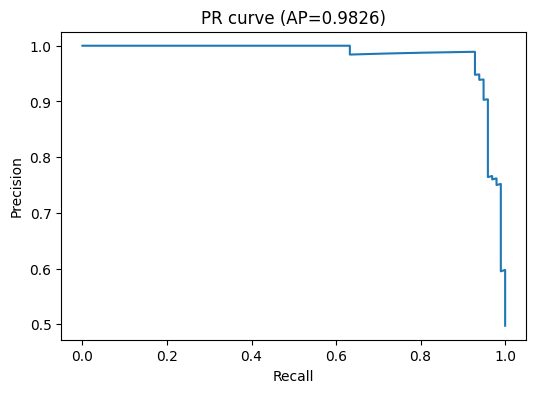


=== Model: RandomForest ===
Classification report (threshold=0.5):
              precision    recall  f1-score   support

           0     0.9505    0.9697    0.9600        99
           1     0.9688    0.9490    0.9588        98

    accuracy                         0.9594       197
   macro avg     0.9596    0.9593    0.9594       197
weighted avg     0.9596    0.9594    0.9594       197

Average precision (AUPRC): 0.9870314675030745
ROC AUC: 0.9823232323232324
Confusion matrix:
 [[96  3]
 [ 5 93]]


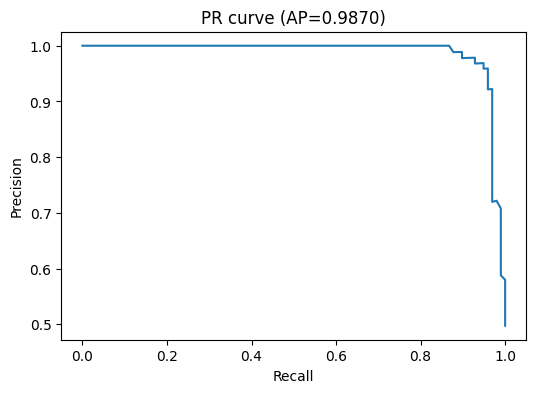


=== Model: XGBoost ===
Classification report (threshold=0.5):
              precision    recall  f1-score   support

           0     0.9495    0.9495    0.9495        99
           1     0.9490    0.9490    0.9490        98

    accuracy                         0.9492       197
   macro avg     0.9492    0.9492    0.9492       197
weighted avg     0.9492    0.9492    0.9492       197

Average precision (AUPRC): 0.9893035208474807
ROC AUC: 0.9851576994434137
Confusion matrix:
 [[94  5]
 [ 5 93]]


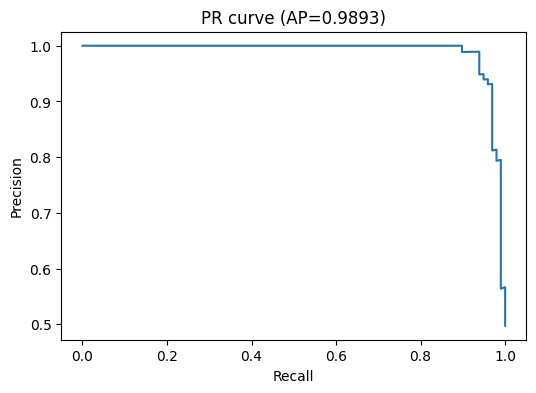

,model,AP,ROC_AUC
2,XGBoost,0.989304,0.985158
1,RandomForest,0.987031,0.982323
0,LogisticRegression,0.982582,0.978664


In [19]:
# 7. Evaluate all trained models
results = []
for name, model in trained_models.items():
    print('\n=== Model:', name, '===') 
    res = evaluate_model(model, X_test_proc, y_test)
    results.append({'model': name, 'AP': res['ap'], 'ROC_AUC': res['roc']})

res_df = pd.DataFrame(results).sort_values('AP', ascending=False)
res_df

In [20]:
# ALWAYS save training columns right after preprocessing
train_columns = X_train_proc.columns


# ---------------- FULL DATA PREP ----------------

def prepare_full_data(df_input):
    X_all = df_input.drop('Class', axis=1).copy()

    # Drop Time BEFORE scaling
    if 'Time' in X_all.columns:
        X_all = X_all.drop(columns=['Time'])

    # Scale numeric features
    X_all[numeric_features] = scaler.transform(X_all[numeric_features])

    # Force exact same column order as training
    X_all = X_all[train_columns]

    return X_all


# Prepare full dataset correctly
X_all_correct = prepare_full_data(df_fe)

# Predict
all_scores = model.predict_proba(X_all_correct)[:, 1]


In [21]:
# # 11. Save the best model
# # prefer saving scikit-learn models; for TF you'd save separately
# joblib.dump(model, 'best_fraud_model.pkl')
# print('Saved best model to best_fraud_model.pkl')

Saved best model to best_fraud_model.pkl
